# Split the Dataset (Train/Test)

In [9]:
import sklearn
from sklearn.model_selection import train_test_split
import pandas as pd

# Load dataset
df = pd.read_csv("../squat_dataset.csv")

# Select correct features based on your dataset
feature_cols = [
    "knee_valgus_mean", "knee_valgus_max", "knee_valgus_min",
    "torso_angle_mean", "torso_angle_max", "torso_angle_min",
    "squat_depth_mean", "squat_depth_max", "squat_depth_min"
]

# Separate features and labels
X = df[feature_cols]
y = df["label"]

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"✅ Training labels: {len(y_train)}, Test labels: {len(y_test)}")

✅ Training samples: 157, Test samples: 40
✅ Training labels: 157, Test labels: 40


# Nested Cross-Validation with Best Parameters Logging

In [12]:
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Define hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Initialize the base model
rf = RandomForestClassifier(random_state=42)

# Outer loop: Stratified K-Fold for evaluation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store scores and best parameters
cv_scores = []
best_params_list = []

# Perform nested cross-validation manually
for train_idx, val_idx in cv_outer.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Inner loop: Grid Search CV
    grid_search = GridSearchCV(rf, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train_fold, y_train_fold)

    # Get best model and evaluate on validation set
    best_model = grid_search.best_estimator_
    val_score = best_model.score(X_val_fold, y_val_fold)

    # Store results
    cv_scores.append(val_score)
    best_params_list.append(grid_search.best_params_)

    print(f"🔍 Fold {len(cv_scores)} - Best Params: {grid_search.best_params_} - Validation Accuracy: {val_score:.4f}")

# Print final results
print(f"\n📊 Nested CV Accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")
print("📝 Best parameters from each fold:")
for i, params in enumerate(best_params_list, 1):
    print(f"  Fold {i}: {params}")
print(f"\n🔥 Best overall parameters: {grid_search.best_params_}")

🔍 Fold 1 - Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50} - Validation Accuracy: 0.9062
🔍 Fold 2 - Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100} - Validation Accuracy: 0.8750
🔍 Fold 3 - Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50} - Validation Accuracy: 1.0000
🔍 Fold 4 - Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200} - Validation Accuracy: 1.0000
🔍 Fold 5 - Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50} - Validation Accuracy: 1.0000

📊 Nested CV Accuracy: 0.9563 ± 0.0545
📝 Best parameters from each fold:
  Fold 1: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
  Fold 2: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  Fold 3: {'max_depth': N

# Train the Final Model

In [13]:
# Train with best params
best_rf = RandomForestClassifier(**grid_search.best_params_, random_state=42)
best_rf.fit(X_train, y_train)

# Save the trained model
import joblib
joblib.dump(best_rf, "trained_rf_model.pkl")

print("✅ Model trained and saved!")

✅ Model trained and saved!


#  Evaluate the Model

In [14]:
from sklearn.metrics import classification_report, roc_auc_score

# Make predictions
y_pred = best_rf.predict(X_test)

# Print evaluation metrics
print(classification_report(y_test, y_pred))
print(f"🏆 ROC-AUC Score: {roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]):.4f}")

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.95      1.00      0.98        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40

🏆 ROC-AUC Score: 1.0000


# Interpretability: Feature Importance

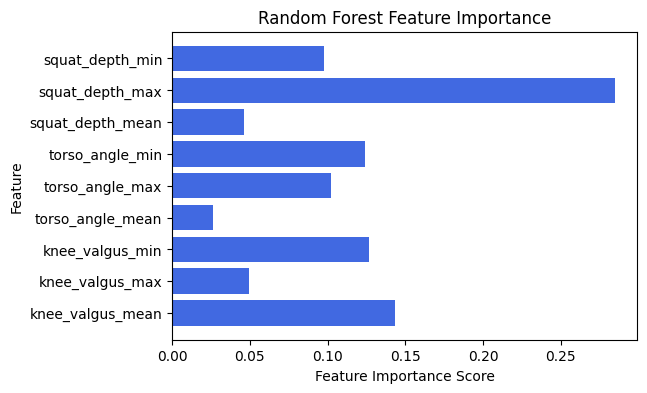

In [15]:
import matplotlib.pyplot as plt

# Get feature importances
importances = best_rf.feature_importances_
features = X_train.columns

# Plot feature importance
plt.figure(figsize=(6, 4))
plt.barh(features, importances, color="royalblue")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.show()